
========== ResNet50 ==========

Processing Cars...
Processing Cats...
Processing Dogs...
Processing Rangoli...


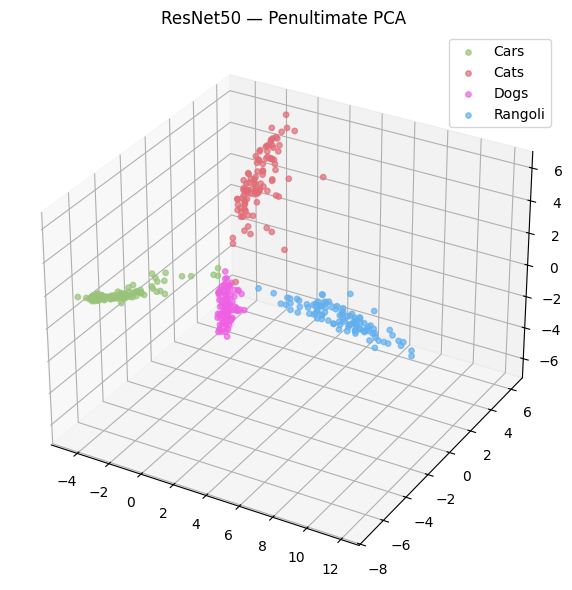

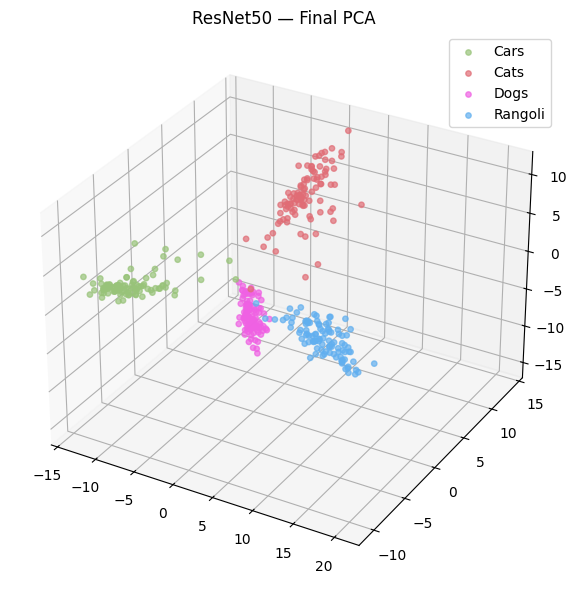


========== VGG16 ==========

Processing Cars...
Processing Cats...
Processing Dogs...
Processing Rangoli...


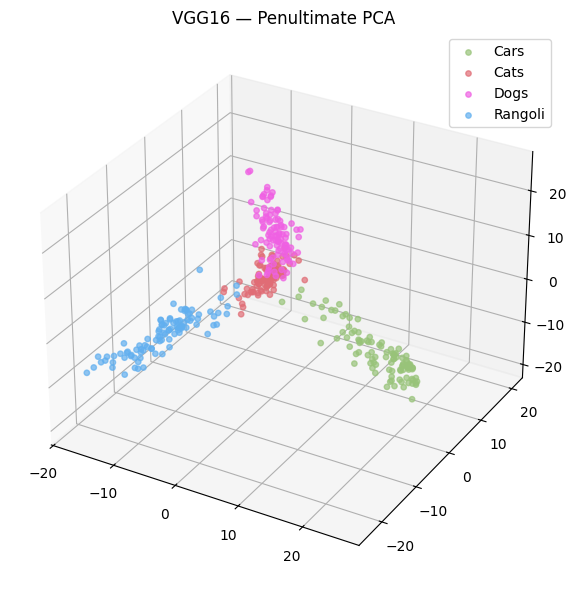

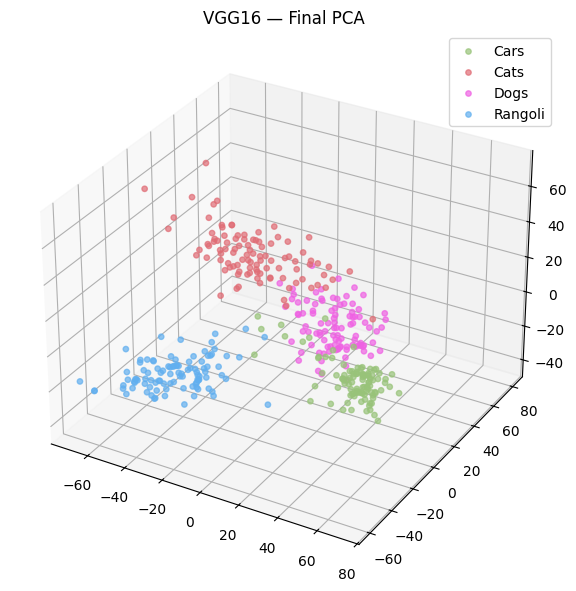


========== Inception ==========

Processing Cars...
Processing Cats...
Processing Dogs...
Processing Rangoli...


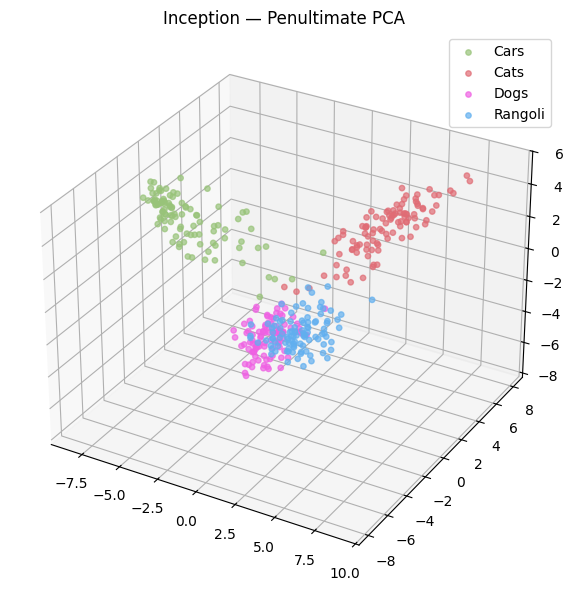

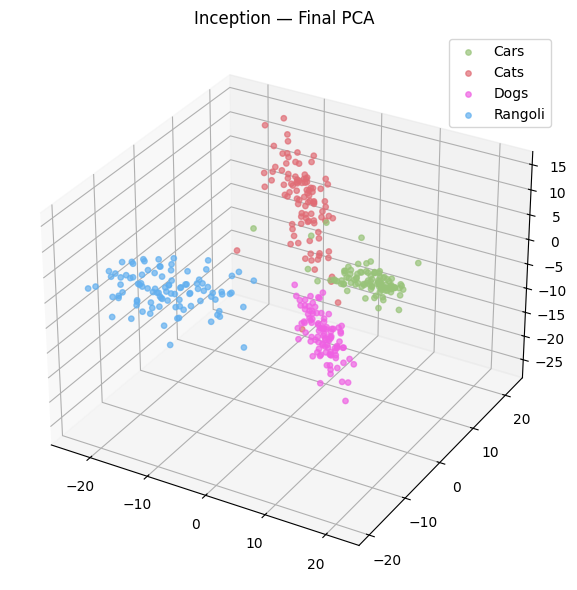


========== MobileNet ==========

Processing Cars...
Processing Cats...
Processing Dogs...
Processing Rangoli...


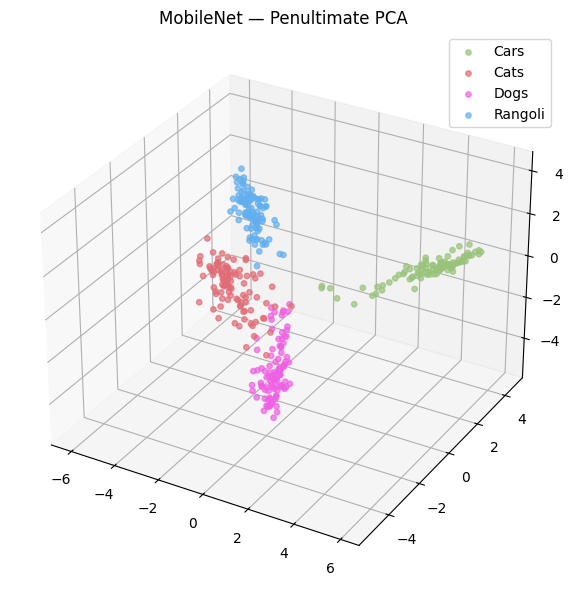

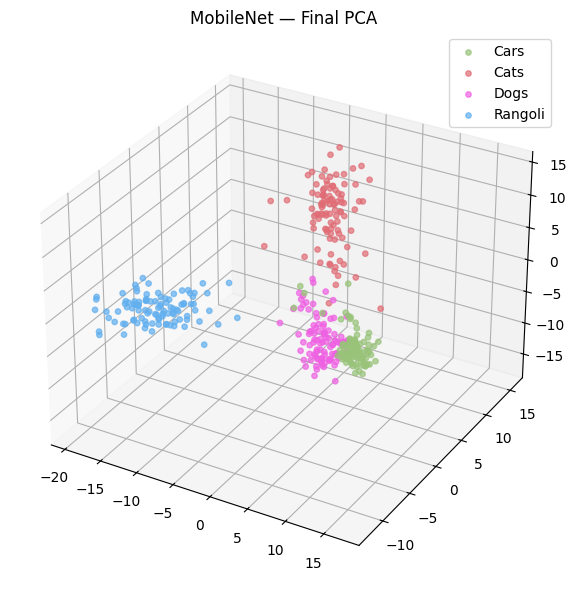

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torchvision import models, transforms
from PIL import Image


# =========================
# CONFIG
# =========================

DATASETS = {
    "Cars": "/Users/jaeeponde/Thesis/Data_100/Cars",
    "Cats": "/Users/jaeeponde/Thesis/Data_100/Cats",
    "Dogs": "/Users/jaeeponde/Thesis/Data_100/Dogs",
    "Rangoli": "/Users/jaeeponde/Thesis/Data_100/Rangoli"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

COLORS = {
    "Cars": "#98C379",
    "Cats": "#E06C75",
    "Dogs": "#EF61E3",
    "Rangoli": "#61AFEF"
}


# =========================
# TRANSFORMS
# =========================

transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_299 = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


# =========================
# MODEL LOADERS
# =========================

def load_resnet():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    return model

def load_vgg():
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    return model

def load_inception():
    model = models.inception_v3(
        weights=models.Inception_V3_Weights.DEFAULT,
        aux_logits=True
    )
    model.AuxLogits = None
    return model

def load_mobilenet():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    return model


# =========================
# HOOK ATTACHMENT
# =========================

def attach_hooks(model, activations):

    def pen_resnet(module, inp, out):
        activations["penultimate"].append(
            out.view(out.size(0), -1).cpu().numpy()
        )

    def pen_vgg(module, inp, out):
        activations["penultimate"].append(out.cpu().numpy())

    def pen_inception(module, inp):
        activations["penultimate"].append(inp[0].cpu().numpy())

    def pen_mobilenet(module, inp, out):
        pooled = out.mean([2,3])
        activations["penultimate"].append(pooled.cpu().numpy())

    def final_hook(module, inp, out):
        activations["final"].append(out.cpu().numpy())

    # attach based on model type
    if isinstance(model, models.ResNet):
        model.avgpool.register_forward_hook(pen_resnet)
        model.fc.register_forward_hook(final_hook)

    elif isinstance(model, models.VGG):
        model.classifier[5].register_forward_hook(pen_vgg)
        model.classifier[6].register_forward_hook(final_hook)

    elif isinstance(model, models.Inception3):
        model.fc.register_forward_pre_hook(pen_inception)
        model.fc.register_forward_hook(final_hook)

    elif isinstance(model, models.MobileNetV2):
        model.features[-1].register_forward_hook(pen_mobilenet)
        model.classifier[1].register_forward_hook(final_hook)


# =========================
# EXTRACTION
# =========================

def extract_activations(model, transform):

    model.to(DEVICE)
    model.eval()

    activations = {"penultimate": [], "final": []}
    attach_hooks(model, activations)

    X_pen, X_fin, labels = [], [], []

    for cls, folder in DATASETS.items():

        print(f"Processing {cls}...")

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".png",".jpeg"))
        ])[:100]

        activations["penultimate"].clear()
        activations["final"].clear()

        for fname in files:

            path = os.path.join(folder, fname)

            try:
                img = Image.open(path).convert("RGB")
                x = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(x)

            except:
                continue

        pen = np.concatenate(activations["penultimate"], axis=0)
        fin = np.concatenate(activations["final"], axis=0)

        X_pen.append(pen)
        X_fin.append(fin)
        labels.extend([cls] * pen.shape[0])

    X_pen = np.vstack(X_pen)
    X_fin = np.vstack(X_fin)
    labels = np.array(labels)

    return X_pen, X_fin, labels


# =========================
# PCA PLOTTING
# =========================

def plot_pca_3d(X, labels, title):

    pca = PCA(n_components=3)
    X_reduced = pca.fit_transform(X)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    for cls in np.unique(labels):

        idx = labels == cls

        ax.scatter(
            X_reduced[idx,0],
            X_reduced[idx,1],
            X_reduced[idx,2],
            label=cls,
            color=COLORS[cls],
            s=15,
            alpha=0.7
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


# =========================
# MAIN PIPELINE
# =========================

def run_all():

    models_dict = {
        "ResNet50": (load_resnet(), transform_224),
        "VGG16": (load_vgg(), transform_224),
        "Inception": (load_inception(), transform_299),
        "MobileNet": (load_mobilenet(), transform_224)
    }

    for name, (model, transform) in models_dict.items():

        print(f"\n========== {name} ==========\n")

        X_pen, X_fin, labels = extract_activations(model, transform)

        # 🔥 Penultimate PCA
        plot_pca_3d(X_pen, labels, f"{name} — Penultimate PCA")

        # 🔥 Final PCA
        plot_pca_3d(X_fin, labels, f"{name} — Final PCA")


if __name__ == "__main__":
    run_all()